In [1]:
# ============================================
# CELL 1: Import Libraries and Get Stock Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries imported!")

# ============================================
# Get stock data for Agilent Technologies (A)
# ============================================

# Download historical data for stock "A"
# Dates: from 2017 to 2020 (matching your news data)
stock = yf.Ticker("A")
df = stock.history(start="2017-01-01", end="2020-12-31")

print(f"Downloaded {len(df)} days of data")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

Libraries imported!
Downloaded 1006 days of data
Date range: 2017-01-03 00:00:00-05:00 to 2020-12-30 00:00:00-05:00

First 5 rows:
                                Open       High        Low      Close  \
Date                                                                    
2017-01-03 00:00:00-05:00  42.774229  43.537888  42.597285  43.295753   
2017-01-04 00:00:00-05:00  43.705528  44.124610  43.603085  43.863846   
2017-01-05 00:00:00-05:00  43.817273  43.835899  43.174683  43.342316   
2017-01-06 00:00:00-05:00  43.426131  44.767189  43.360941  44.692688   
2017-01-09 00:00:00-05:00  44.711309  45.223523  44.618182  44.832378   

                            Volume  Dividends  Stock Splits  
Date                                                         
2017-01-03 00:00:00-05:00  1739600        0.0           0.0  
2017-01-04 00:00:00-05:00  1821300        0.0           0.0  
2017-01-05 00:00:00-05:00  1503700        0.0           0.0  
2017-01-06 00:00:00-05:00  2883400        0.0  

In [2]:
# ============================================
# CELL 2: Basic Stock Data Exploration
# ============================================

print("=" * 50)
print("STOCK DATA OVERVIEW")
print("=" * 50)

print(f"Total trading days: {len(df)}")
print(f"Start date: {df.index.min().date()}")
print(f"End date: {df.index.max().date()}")

# Price range
print(f"\nPrice range:")
print(f"  Lowest price: ${df['Low'].min():.2f}")
print(f"  Highest price: ${df['High'].max():.2f}")

# Volume statistics
print(f"\nTrading Volume:")
print(f"  Average daily volume: {df['Volume'].mean():,.0f} shares")
print(f"  Highest volume day: {df['Volume'].max():,.0f} shares")

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

STOCK DATA OVERVIEW
Total trading days: 1006
Start date: 2017-01-03
End date: 2020-12-30

Price range:
  Lowest price: $42.60
  Highest price: $115.75

Trading Volume:
  Average daily volume: 2,113,295 shares
  Highest volume day: 14,523,800 shares

Missing values: 0


In [4]:
# ============================================
# CELL 3: Import TA-Lib (Replacement for pandas_ta)
# ============================================

import talib as ta

print("TA-Lib imported!")


TA-Lib imported!


In [5]:
# ============================================
# CELL 4: Calculate Technical Indicators
# ============================================

# Make a copy to work with
stock_df = df.copy()

# 1. Moving Averages
stock_df['SMA_20'] = ta.SMA(stock_df['Close'], timeperiod=20)  # 20-day Simple Moving Average
stock_df['SMA_50'] = ta.SMA(stock_df['Close'], timeperiod=50)  # 50-day Simple Moving Average
stock_df['EMA_12'] = ta.EMA(stock_df['Close'], timeperiod=12)  # 12-day Exponential Moving Average

# 2. RSI (Relative Strength Index)
stock_df['RSI_14'] = ta.RSI(stock_df['Close'], timeperiod=14)  # 14-day RSI

# 3. MACD (Moving Average Convergence Divergence)
macd, macd_signal, macd_hist = ta.MACD(stock_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
stock_df['MACD'] = macd
stock_df['MACD_signal'] = macd_signal
stock_df['MACD_histogram'] = macd_hist

# 4. Bollinger Bands (volatility indicator)
bb_upper, bb_middle, bb_lower = ta.BBANDS(stock_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
stock_df['BB_upper'] = bb_upper
stock_df['BB_middle'] = bb_middle
stock_df['BB_lower'] = bb_lower

# 5. Volume indicators
stock_df['OBV'] = ta.OBV(stock_df['Close'], stock_df['Volume'])  # On-Balance Volume

print("Indicators calculated!")
print(f"\nNew columns added: {[col for col in stock_df.columns if col not in df.columns]}")

Indicators calculated!

New columns added: ['SMA_20', 'SMA_50', 'EMA_12', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV']


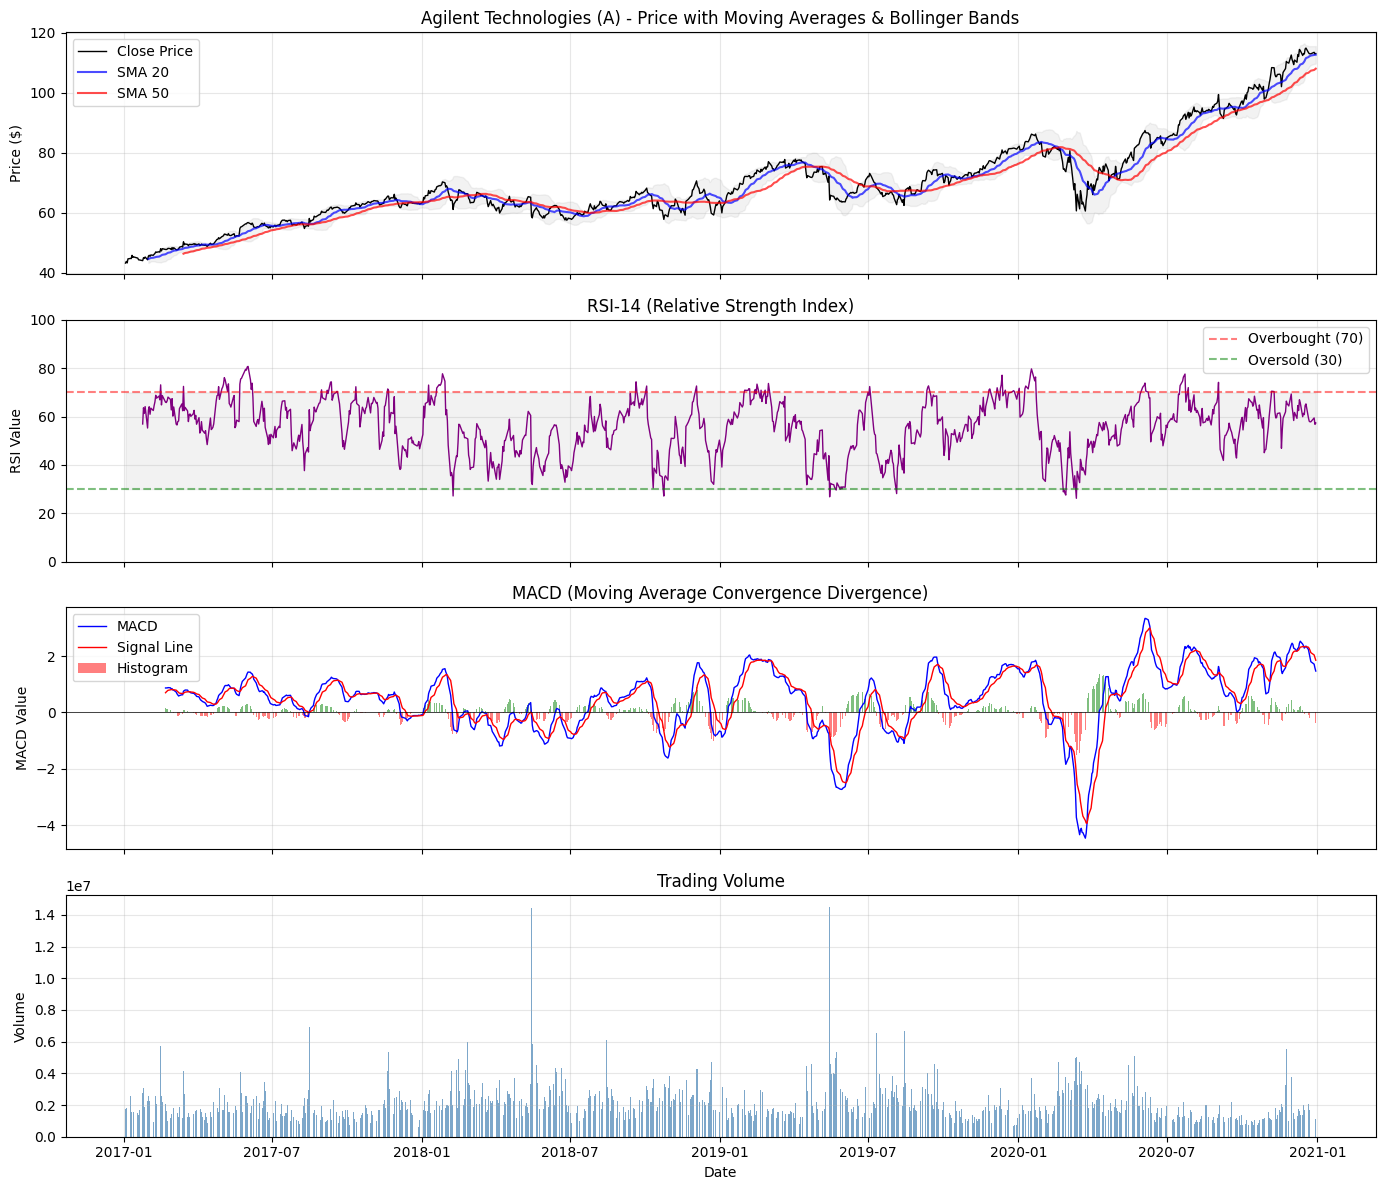

Chart saved as 'technical_indicators.png'


In [6]:
# ============================================
# CELL 5: Create Technical Indicators Chart
# ============================================

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Chart 1: Price with Moving Averages
axes[0].plot(stock_df.index, stock_df['Close'], label='Close Price', color='black', linewidth=1)
axes[0].plot(stock_df.index, stock_df['SMA_20'], label='SMA 20', color='blue', alpha=0.7)
axes[0].plot(stock_df.index, stock_df['SMA_50'], label='SMA 50', color='red', alpha=0.7)
axes[0].fill_between(stock_df.index, stock_df['BB_lower'], stock_df['BB_upper'], alpha=0.1, color='gray')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Agilent Technologies (A) - Price with Moving Averages & Bollinger Bands')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: RSI
axes[1].plot(stock_df.index, stock_df['RSI_14'], color='purple', linewidth=1)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].fill_between(stock_df.index, 30, 70, alpha=0.1, color='gray')
axes[1].set_ylabel('RSI Value')
axes[1].set_title('RSI-14 (Relative Strength Index)')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: MACD
axes[2].plot(stock_df.index, stock_df['MACD'], label='MACD', color='blue', linewidth=1)
axes[2].plot(stock_df.index, stock_df['MACD_signal'], label='Signal Line', color='red', linewidth=1)

# MACD Histogram (bars)
colors = ['green' if val >= 0 else 'red' for val in stock_df['MACD_histogram']]
axes[2].bar(stock_df.index, stock_df['MACD_histogram'], color=colors, alpha=0.5, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('MACD Value')
axes[2].set_title('MACD (Moving Average Convergence Divergence)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# Chart 4: Volume
axes[3].bar(stock_df.index, stock_df['Volume'], color='steelblue', alpha=0.7)
axes[3].set_ylabel('Volume')
axes[3].set_xlabel('Date')
axes[3].set_title('Trading Volume')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as 'technical_indicators.png'")

In [7]:
# ============================================
# CELL 6: Identify Trading Signals
# ============================================

print("=" * 50)
print("TRADING SIGNALS ANALYSIS")
print("=" * 50)

# Get the last 30 days of data for analysis
recent = stock_df.tail(30)

# 1. Moving Average Signals
last_price = recent['Close'].iloc[-1]
last_sma20 = recent['SMA_20'].iloc[-1]
last_sma50 = recent['SMA_50'].iloc[-1]

print(f"\n📊 Moving Average Analysis:")
if last_price > last_sma20 and last_price > last_sma50:
    print("   ✅ Price is above both moving averages - UPTREND")
    print("      (Good time to consider buying)")
elif last_price < last_sma20 and last_price < last_sma50:
    print("   ⚠️ Price is below both moving averages - DOWNTREND")
    print("      (Be cautious, consider selling)")
else:
    print("   ⚠️ Price is between moving averages - TRENDING SIDEWAYS")
    print("      (Wait for clearer signal)")

# 2. RSI Signals
last_rsi = recent['RSI_14'].iloc[-1]
print(f"\n📈 RSI Analysis (Current: {last_rsi:.1f}):")
if last_rsi > 70:
    print("   🔴 RSI > 70 - OVERBOUGHT")
    print("      (Stock may be too expensive - Consider SELLING)")
elif last_rsi < 30:
    print("   🟢 RSI < 30 - OVERSOLD")
    print("      (Stock may be cheap - Consider BUYING)")
else:
    print("   ⚪ RSI is neutral - No extreme signal")

# 3. MACD Signals
last_macd = recent['MACD'].iloc[-1]
last_signal = recent['MACD_signal'].iloc[-1]
print(f"\n📉 MACD Analysis:")
if last_macd > last_signal:
    print("   🟢 MACD above Signal Line - BULLISH MOMENTUM")
    print("      (Positive price movement expected)")
else:
    print("   🔴 MACD below Signal Line - BEARISH MOMENTUM")
    print("      (Negative price movement expected)")

# Check for crossovers in last 5 days
crossover = False
for i in range(-5, 0):
    if recent['MACD'].iloc[i] > recent['MACD_signal'].iloc[i] and recent['MACD'].iloc[i-1] <= recent['MACD_signal'].iloc[i-1]:
        print("   🟢 BULLISH CROSSOVER detected in last 5 days!")
        crossover = True
    elif recent['MACD'].iloc[i] < recent['MACD_signal'].iloc[i] and recent['MACD'].iloc[i-1] >= recent['MACD_signal'].iloc[i-1]:
        print("   🔴 BEARISH CROSSOVER detected in last 5 days!")
        crossover = True

if not crossover:
    print("   No recent MACD crossover signals")

TRADING SIGNALS ANALYSIS

📊 Moving Average Analysis:
   ✅ Price is above both moving averages - UPTREND
      (Good time to consider buying)

📈 RSI Analysis (Current: 57.3):
   ⚪ RSI is neutral - No extreme signal

📉 MACD Analysis:
   🔴 MACD below Signal Line - BEARISH MOMENTUM
      (Negative price movement expected)
   No recent MACD crossover signals


In [8]:
# ============================================
# CELL 7: Summary Statistics
# ============================================

print("\n" + "=" * 50)
print("TECHNICAL INDICATORS SUMMARY")
print("=" * 50)

# Price statistics
print(f"\n💰 PRICE STATISTICS (Full Period):")
print(f"   Average Close Price: ${stock_df['Close'].mean():.2f}")
print(f"   Price Standard Deviation: ${stock_df['Close'].std():.2f}")
print(f"   Price Change (Start to End): ${stock_df['Close'].iloc[-1] - stock_df['Close'].iloc[0]:.2f}")
print(f"   Total Return: {(stock_df['Close'].iloc[-1] / stock_df['Close'].iloc[0] - 1) * 100:.1f}%")

# RSI statistics
print(f"\n📊 RSI STATISTICS:")
print(f"   Average RSI: {stock_df['RSI_14'].mean():.1f}")
print(f"   Days Overbought (RSI > 70): {(stock_df['RSI_14'] > 70).sum()}")
print(f"   Days Oversold (RSI < 30): {(stock_df['RSI_14'] < 30).sum()}")

# Volume statistics
print(f"\n📈 VOLUME STATISTICS:")
print(f"   Average Daily Volume: {stock_df['Volume'].mean():,.0f}")
print(f"   Highest Volume Day: {stock_df['Volume'].max():,.0f}")

print("\n✅ Task 2 Complete!")


TECHNICAL INDICATORS SUMMARY

💰 PRICE STATISTICS (Full Period):
   Average Close Price: $69.79
   Price Standard Deviation: $14.63
   Price Change (Start to End): $69.71
   Total Return: 161.0%

📊 RSI STATISTICS:
   Average RSI: 55.9
   Days Overbought (RSI > 70): 94
   Days Oversold (RSI < 30): 11

📈 VOLUME STATISTICS:
   Average Daily Volume: 2,113,295
   Highest Volume Day: 14,523,800

✅ Task 2 Complete!


In [9]:
# ============================================
# CELL 8: Save results to CSV
# ============================================

# Save the dataframe with indicators
stock_df.to_csv('agilent_technical_indicators.csv')
print("Saved indicators to 'agilent_technical_indicators.csv'")

Saved indicators to 'agilent_technical_indicators.csv'
